<a href="https://colab.research.google.com/github/jsansao/teic_tp_mock/blob/main/tp2_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 2 (TP2) - Ciência de Dados
## Dataset: IMDB (Mineração de Texto e Análise de Frequência de Termos)

Este notebook apresenta a resolução da segunda etapa (TP2) para o dataset de críticas de cinema IMDB. O foco desta etapa é a **Análise Exploratória de Dados (EDA) Textual**, pré-processamento de texto (limpeza de tags HTML, pontuações e stop words) e vetorização matemática utilizando representações estatísticas de palavras (TF-IDF).

---

## 1. Revisão da Formalização do Problema e Objetivos

### 1.1 Resumo do Problema
O objetivo é classificar a polaridade sentimental de críticas de filmes escritas em inglês no IMDB. Trata-se de uma tarefa de **classificação binária supervisionada** ($Y \in \{0, 1\}$, representando críticas negativas ou positivas). O input original consiste em strings de texto de comprimento variado e sem estrutura definida.

### 1.2 Objetivos Pretendidos
*   Analisar estatisticamente a distribuição de comprimentos de palavras e caracteres das avaliações.
*   Limpar os textos removendo ruídos comuns da web (como tags HTML `<br />`) e caracteres de pontuação.
*   Identificar os termos mais frequentes associados a avaliações positivas e negativas.
*   Vetorizar o texto em um espaço numérico através do modelo TF-IDF, preparando a base para modelagem clássica e profunda no TP3.

---

## 2. Análise Exploratória dos Dados (EDA) e Transformações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregando a amostra de 2.000 instâncias do IMDB
url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
df = pd.read_csv(url)
df_sub = df.sample(n=2000, random_state=42).reset_index(drop=True)

print(f"Amostra reduzida: {df_sub.shape[0]} críticas de cinema.")
df_sub.head()

Amostra reduzida: 2000 críticas de cinema.


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


### 2.1 A base de dados é adequada?
Sim, o IMDB é adequado por possuir críticas reais e detalhadas de usuários, o que o torna desafiador devido ao uso de ironias, gírias e pontuações expressivas, sendo representativo de problemas reais de processamento de texto.

### 2.2 Existem dados faltantes?
Vamos checar a presença de nulos nas colunas de texto e de rótulo.

In [2]:
print("Dados nulos por coluna:")
df_sub.isnull().sum()

Dados nulos por coluna:


,0
review,0
sentiment,0


Não existem dados faltantes. Todas as observações contêm a string da avaliação e a respectiva categoria de sentimento.

### 2.3 Análise Estatística do Comprimento das Críticas

Vamos analisar a distribuição de contagem de palavras em críticas positivas e negativas.

In [3]:
# Computar o número de palavras por crítica
df_sub['word_count'] = df_sub['review'].apply(lambda x: len(x.split()))

print("Estatísticas da contagem de palavras por sentimento:")
df_sub.groupby('sentiment')['word_count'].describe()

Estatísticas da contagem de palavras por sentimento:


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,1024.0,230.433594,176.082579,19.0,123.00,172.0,269.25,1010.0
positive,976.0,233.865779,167.640291,28.0,125.75,176.5,294.00,998.0


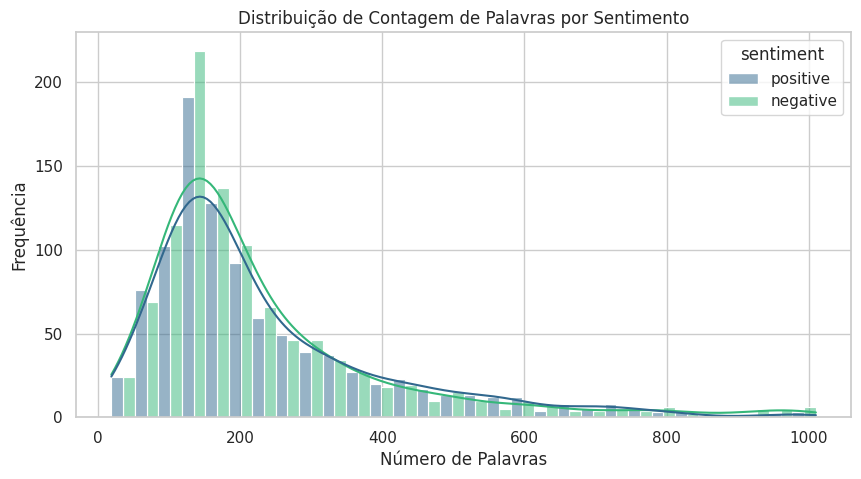

In [4]:
# Plot da distribuição do tamanho dos textos
plt.figure(figsize=(10, 5))
sns.histplot(data=df_sub, x='word_count', hue='sentiment', kde=True, multiple='dodge', bins=30, palette='viridis')
plt.title('Distribuição de Contagem de Palavras por Sentimento')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
plt.show()

### 2.4 Pré-processamento e Limpeza Textual

Para alimentar algoritmos numéricos, precisamos padronizar o texto. A função a seguir executa:
1.  Remoção de tags HTML (ex: `<br />`).
2.  Conversão para letras minúsculas.
3.  Remoção de pontuações e caracteres especiais, mantendo apenas caracteres alfanuméricos simples.

In [5]:
def clean_text(text):
    # Remover tags HTML
    text = re.sub(r'<br\s*/?>', ' ', text)
    # Converter para minúsculas
    text = text.lower()
    # Remover caracteres especiais e manter apenas letras e espaços
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remover espaços múltiplos
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplicar limpeza
df_sub['clean_review'] = df_sub['review'].apply(clean_text)
print("Texto original:\n", df_sub['review'].iloc[0][:150] + "...")
print("-" * 50)
print("Texto limpo:\n", df_sub['clean_review'].iloc[0][:150] + "...")

Texto original:
 I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, th...
--------------------------------------------------
Texto limpo:
 i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason anyways this ...


### 2.5 Identificação de Termos Frequentes por Classe
Vamos extrair as 15 palavras mais comuns associadas a sentimentos positivos e negativos, excluindo as *stop words* (palavras de ligação comuns da língua inglesa que não agregam valor semântico, como 'the', 'is', 'and').

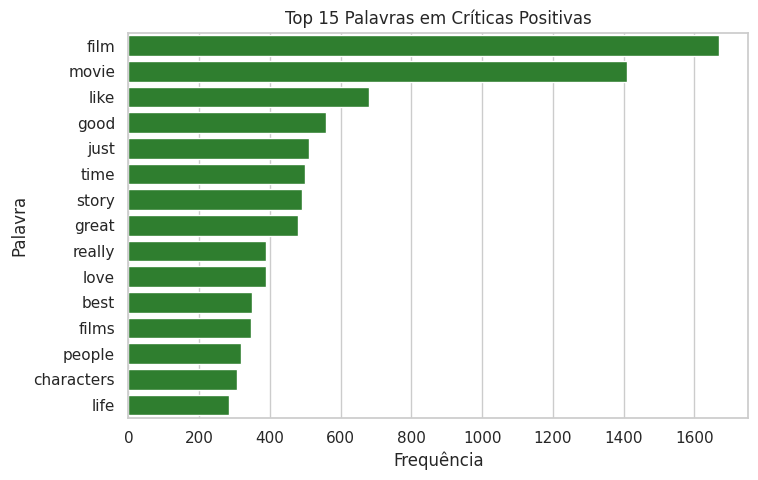

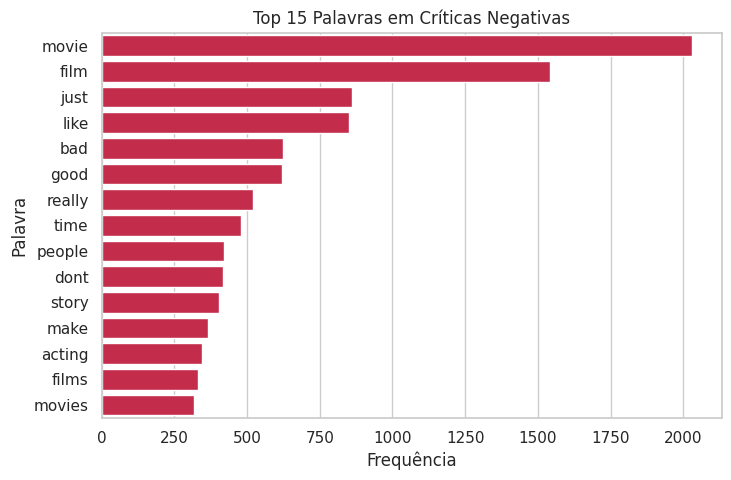

In [6]:
# Função para obter frequências de palavras excluindo stop words em inglês
def plot_top_words(texts, title, color):
    vectorizer = CountVectorizer(stop_words='english', max_features=15)
    word_counts = vectorizer.fit_transform(texts)

    sum_words = word_counts.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    words_df = pd.DataFrame(words_freq, columns=['Palavra', 'Frequência'])

    sns.barplot(data=words_df, y='Palavra', x='Frequência', color=color)
    plt.title(title)
    plt.show()

# 1. Palavras mais comuns em avaliações positivas
plt.figure(figsize=(8, 5))
plot_top_words(df_sub[df_sub['sentiment'] == 'positive']['clean_review'],
               "Top 15 Palavras em Críticas Positivas", "forestgreen")

# 2. Palavras mais comuns em avaliações negativas
plt.figure(figsize=(8, 5))
plot_top_words(df_sub[df_sub['sentiment'] == 'negative']['clean_review'],
               "Top 15 Palavras em Críticas Negativas", "crimson")

### 2.6 Vetorização Matemática (TF-IDF)
Após a limpeza do texto bruto, convertemos cada crítica em um vetor numérico pelo método **TF-IDF** (*Term Frequency - Inverse Document Frequency*). Essa representação penaliza termos que ocorrem excessivamente em todos os documentos (ex: 'movie', 'film') e valoriza palavras que possuem maior poder discriminatório na avaliação.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vetorização TF-IDF limitando em 1.000 termos e n-grams de 1 a 2 palavras (monogramas e bigramas)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df_sub['clean_review']).toarray()

# Mapeando variável alvo para binário (positive=1, negative=0)
y = df_sub['sentiment'].map({'positive': 1, 'negative': 0}).values

print("Dimensão da matriz de features TF-IDF (amostras, vocabulário):", X_tfidf.shape)
print("Dimensão do vetor de labels:", y.shape)

Dimensão da matriz de features TF-IDF (amostras, vocabulário): (2000, 1000)
Dimensão do vetor de labels: (2000,)


---

## 3. Principais Decisões de Projeto

### 3.1 Descrição das Decisões
1.  **Limpeza Textual via Expressões Regulares:** Remoção de marcações de layout HTML (`<br />`) que poluem o vocabulário, e conversão total para minúsculas.
2.  **Exclusão de Stop Words:** Palavras funcionais em inglês (ex: 'it', 'they', 'was') foram removidas, já que sua alta frequência não carrega teor sentimental.
3.  **ngram_range=(1, 2):** Decidimos incluir bigramas (combinação de duas palavras consecutivas) como "not good" ou "very bad" para capturar negações e intensidades comuns em reviews textuais.
4.  **Limite de Vocabulário em 1.000 Features:** Reduz a dimensão do espaço amostral, mitigando a esparsidade extrema de texto e mantendo o processamento rápido.

### 3.2 Revisão da Literatura
*   **Maas et al. (2011)** provam que etapas de pré-processamento de texto estruturado e o uso de matrizes de frequência constituem o ponto de partida padrão para modelagem de sentimento.
*   **Pang e Lee (2002)** demonstram que monogramas em combinação com termos de negação (capturados por bigramas) são fundamentais para classificar polaridades de críticas de cinema de forma robusta.

### 3.3 Avaliação do Impacto na Próxima Etapa
No TP3, avaliaremos o impacto dessa vetorização testando a diferença de acurácia de modelos tradicionais alimentados com:
*   *Configuração A:* TF-IDF simples apenas com monogramas (`ngram_range=(1,1)`).
*   *Configuração B:* TF-IDF com monogramas e bigramas (`ngram_range=(1,2)`).

---

## 4. Metodologia de Modelagem e Simulação Computacional (TP3)

### 4.1 Algoritmos de Machine / Deep Learning Pretendidos
Para a etapa prática de modelagem manual (TP3), selecionamos os seguintes algoritmos:
1.  **Multinomial Naive Bayes (MNB):** Modelo probabilístico clássico de baseline para processamento de texto devido ao seu alto desempenho sob suposições de independência de termos.
2.  **Regressão Logística (LR):** Classificador linear robusto para dados esparsos de alta dimensão com regularização L2.
3.  **Rede Neural Recorrente (LSTM ou GRU):** Rede neural profunda sequencial que processa o texto como uma sequência ordenada de palavras (utilizando *Word Embeddings*), avaliando o ganho de modelos profundos que consideram a ordem textual em relação aos sacos de palavras (bag-of-words/TF-IDF).

### 4.2 Métricas de Desempenho
*   **Acurácia Global:** Como a amostra é perfeitamente balanceada (1.000 positivas, 1.000 negativas), serve como métrica de sucesso principal.
*   **Precisão e Recall (Revocação):** Para inspecionar se o classificador erra mais ao prever elogios falsos ou críticas negativas falsas.
*   **F1-Score:** Indicador balanceado geral de desempenho.

### 4.3 Referências de Comparação
Compararemos as implementações manuais do TP3 com:
1.  A estimativa estatística de **chute aleatório** (Acurácia teórica de 50%).
2.  A Prova de Conceito automática de AutoML obtida via **FLAML no TP1** (Acurácia: ~82%).
